In [14]:
# ==============================================================
# Pipeline — FRB Isotropy Test
# ==============================================================

import numpy as np
import pandas as pd
import treecorr
import os
from tqdm.auto import tqdm
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ks_2samp
import seaborn as sns

In [2]:
# ==============================================================
# 1. General Configurations
# ==============================================================

# -----------------------------
# Data paths
# -----------------------------
# 15 Northern subsamples (CHIME-dominated) + 1 Southern catalog
BASE_PATH = "/home/brunowesley/projetos/FRB-isotropy-tests/FRB_catalogs/"
NORTH_PATHS = [os.path.join(BASE_PATH, f"SkyPosition_North{i}.csv") for i in range(1, 16)]
SOUTH_PATH = os.path.join(BASE_PATH, "SkyPosition_South.csv")

# -----------------------------
# Monte Carlo parameters
# -----------------------------
# Random catalog size relative to data
N_RAND_FACTOR = 20

# Number of isotropic mock realizations (H0)
N_MOCKS = 200

# -----------------------------
# Observational mask
# -----------------------------
# Galactic latitude cut (degrees)
GAL_CUT = 20.0

# -----------------------------
# Angular correlation settings
# -----------------------------
USE_LOG = False       # Log or linear binning
MAX_SEP = 180.0       # Maximum angular separation (deg)

# Minimum separation (>0 to avoid singularities)
MIN_SEP = 0.1

# -----------------------------
# 2pACF binning
# -----------------------------
if USE_LOG:
    BIN_TYPE = 'Log'
    N_BINS = 20
else:
    BIN_TYPE = 'Linear'
    BIN_SIZE = 1.8
    N_BINS = int((MAX_SEP - MIN_SEP) / BIN_SIZE)

# -----------------------------
# Coarse bins (Absolute Sum Test)
# -----------------------------
COARSE_BINS = np.arange(0, 181, 20)
COARSE_CENTERS = 0.5 * (COARSE_BINS[:-1] + COARSE_BINS[1:])

In [3]:
# ==============================================================
# 2. Mask function
# ==============================================================

def apply_mask(df):
    """
    Apply:
    - coordinate cuts (RA/DEC ranges)
    - Galactic mask: |b| > GAL_CUT
    """

    # Convert to Galactic coordinates
    coords = SkyCoord(ra=df['RA'].values*u.degree,
                      dec=df['DEC'].values*u.degree,
                      frame='icrs')

    b = coords.galactic.b.degree

    # Apply geometric + Galactic cuts
    mask = (
        (df["RA"] >= 0) & (df["RA"] <= 360) &
        (df["DEC"] >= -90) & (df["DEC"] <= 90) &
        (np.abs(b) > GAL_CUT)
    )

    return df[mask].reset_index(drop=True)


# ==============================================================
# 3. Isotropic catalog generator
# ==============================================================

def generate_isotropic_catalog(n, seed=None):
    """
    Generate isotropic sky:
    - RA ~ U(0, 360)
    - DEC via arcsin sampling (uniform on sphere)
    """

    rng = np.random.default_rng(seed)

    ra = 360.0 * rng.random(n)
    dec = np.degrees(np.arcsin(2.0 * rng.random(n) - 1.0))

    return pd.DataFrame({"RA": ra, "DEC": dec})

In [4]:
# ==============================================================
# 4. 2pACF computation (Landy–Szalay)
# ==============================================================

def compute_2pacf(df_data, df_rand, log_spacing=False):
    """
    Compute angular two-point correlation function (2pACF)
    using the Landy–Szalay estimator.
    """

    # Build TreeCorr catalogs
    cat_data = treecorr.Catalog(
        ra=df_data["RA"], dec=df_data["DEC"],
        ra_units="deg", dec_units="deg"
    )

    cat_rand = treecorr.Catalog(
        ra=df_rand["RA"], dec=df_rand["DEC"],
        ra_units="deg", dec_units="deg"
    )

    # Bin type
    bin_type = 'Log' if log_spacing else 'Linear'

    # Correlation object
    corr = treecorr.NNCorrelation(
        min_sep=MIN_SEP,
        max_sep=MAX_SEP,
        nbins=N_BINS,
        sep_units="deg",
        metric='Arc',
        bin_type=bin_type
        # Use default bin_slop (optimized)
    )

    rr = treecorr.NNCorrelation(**corr.config)
    dr = treecorr.NNCorrelation(**corr.config)

    # Pair counts
    corr.process(cat_data)
    rr.process(cat_rand)
    dr.process(cat_data, cat_rand)

    # Landy–Szalay estimator
    corr.calculateXi(rr=rr, dr=dr)

    # Angular bin centers (consistent with pair counts)
    theta = np.exp(corr.meanlogr)

    return theta, corr.xi


# ==============================================================
# 5. Absolute Sum Test (tomographic)
# ==============================================================

def get_absolute_sum(theta, w):
    """
    Compress 2pACF into coarse angular bins:
    mean w(θ) per bin → absolute value
    """
    
    vals = []

    for i in range(len(COARSE_BINS) - 1):
        mask = (theta >= COARSE_BINS[i]) & (theta < COARSE_BINS[i+1])

        if np.any(mask):
            vals.append(np.abs(np.mean(w[mask])))
        else:
            vals.append(0.0)

    return np.array(vals)


# ==============================================================
# 6. Catalog loader
# ==============================================================

def load_catalog(path):
    """Load RA/DEC columns and drop NaNs."""

    return pd.read_csv(path)[["RA", "DEC"]].dropna()

In [5]:
# ==============================================================
# 7. Observational data (15 ensembles)
# ==============================================================

# Southern catalog (fixed reference)
frb_south = apply_mask(load_catalog(SOUTH_PATH))

all_w_obs = []
all_abs_obs = []

print(f"\n--- Processando dados reais ({BIN_TYPE}) ---")

for i, path in enumerate(tqdm(NORTH_PATHS)):

    # Load and mask Northern subsample
    frb_north = apply_mask(load_catalog(path))

    # Combine North + South
    df_data = pd.concat([frb_north, frb_south], ignore_index=True)

    # Isotropic random catalog (same mask applied)
    df_rand = apply_mask(
        generate_isotropic_catalog(len(df_data)*N_RAND_FACTOR, seed=2000+i)
    )

    # 2pACF
    theta, w = compute_2pacf(df_data, df_rand, log_spacing=USE_LOG)

    # Store statistics
    all_w_obs.append(w)
    all_abs_obs.append(get_absolute_sum(theta, w))

# Convert to arrays
all_w_obs = np.array(all_w_obs)
all_abs_obs = np.array(all_abs_obs)

# Ensemble averages
mean_w_obs = np.mean(all_w_obs, axis=0)
mean_abs_obs = np.mean(all_abs_obs, axis=0)


--- Processando dados reais (Linear) ---


  0%|          | 0/15 [00:00<?, ?it/s]

In [6]:
# ==============================================================
# 8. H0 — isotropic universe (observed through mask)
# ==============================================================

print("\n--- Generating H0 mocks ---")

# Average number of sources (after mask)
n_avg = int(np.mean([
    len(apply_mask(load_catalog(p)))
    for p in NORTH_PATHS
]) + len(frb_south))

# Storage
all_w_h0 = []
all_abs_h0 = []

for i in tqdm(range(N_MOCKS)):

    # Isotropic sky + observational mask
    d_iso = apply_mask(generate_isotropic_catalog(n_avg, seed=i))
    
    # Random catalog (same selection)
    r_iso = apply_mask(generate_isotropic_catalog(len(d_iso)*N_RAND_FACTOR, seed=i+5000))

    # 2pACF
    _, w = compute_2pacf(d_iso, r_iso, log_spacing=USE_LOG)

    # Store statistics
    all_w_h0.append(w)
    all_abs_h0.append(get_absolute_sum(theta, w))

# Convert to arrays
all_w_h0 = np.array(all_w_h0)
all_abs_h0 = np.array(all_abs_h0)

# H0 statistics
h0_mean = np.mean(all_w_h0, axis=0)
h0_std = np.std(all_w_h0, axis=0)

h0_abs_mean = np.mean(all_abs_h0, axis=0)
h0_abs_std = np.std(all_abs_h0, axis=0)


--- Generating H0 mocks ---


  0%|          | 0/200 [00:00<?, ?it/s]

In [7]:
# ==============================================================
# 9. Statistical tests
# ==============================================================

print("\n--- Statistical tests ---")

# χ² using covariance matrix from mocks
cov = np.cov(all_w_h0, rowvar=False)
inv_cov = np.linalg.pinv(cov)

delta = mean_w_obs - h0_mean
chi2 = delta @ inv_cov @ delta
dof = len(delta)

print(f"Chi2 = {chi2:.2f}")
print(f"Chi2/dof = {chi2/dof:.2f}")

# KS test on Absolute Sum (distribution-level comparison)
ks_stat, ks_p = ks_2samp(mean_abs_obs, h0_abs_mean)

print(f"\nKS statistic = {ks_stat:.4f}")
print(f"KS p-value   = {ks_p:.4e}")


--- Statistical tests ---
Chi2 = 642.13
Chi2/dof = 6.49

KS statistic = 0.7778
KS p-value   = 6.2937e-03


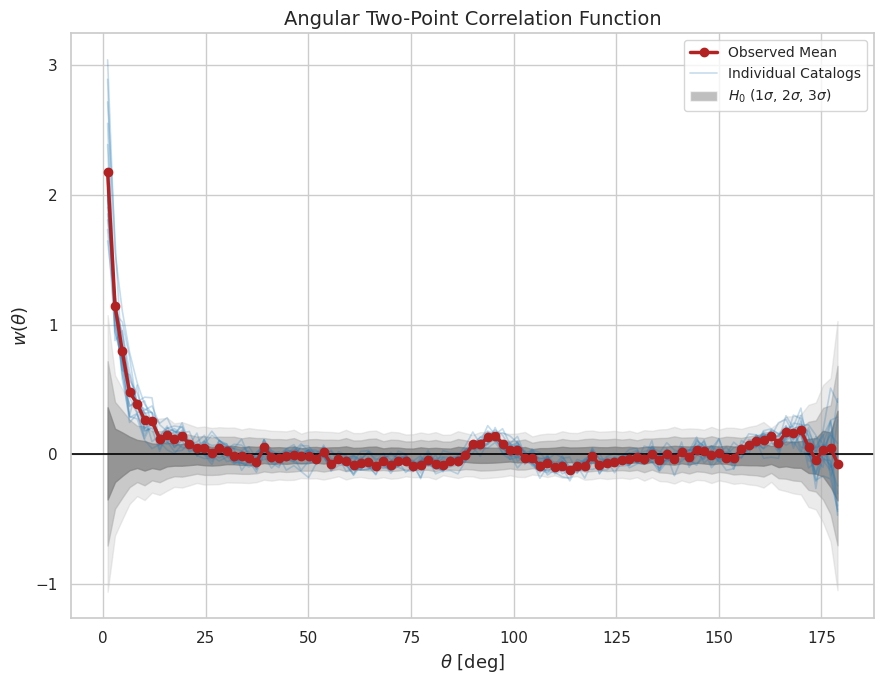

In [17]:
# ==============================================================
# 10 Visualization
# ==============================================================

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 10
})

# ==============================================================
# PLOT 1 — 2pACF
# ==============================================================

fig, ax = plt.subplots(figsize=(9,7))

# --- H0 confidence bands (sem label) ---
ax.fill_between(theta, h0_mean - 3*h0_std, h0_mean + 3*h0_std,
                color='silver', alpha=0.3)

ax.fill_between(theta, h0_mean - 2*h0_std, h0_mean + 2*h0_std,
                color='darkgray', alpha=0.5)

ax.fill_between(theta, h0_mean - h0_std, h0_mean + h0_std,
                color='gray', alpha=0.7)


# --- Individual catalogs ---
for i, w in enumerate(all_w_obs):
    ax.plot(theta, w,
            color='tab:blue',
            alpha=0.25,
            lw=1.2,
            label="Individual Catalogs" if i == 0 else None)


# --- Observed mean ---
ax.plot(theta, mean_w_obs,
        'o-', color='firebrick',
        markersize=6, lw=2.5,
        label='Observed Mean',
        zorder=10)


# --- Axis settings ---
if USE_LOG:
    ax.set_xscale('log')

ax.axhline(0, color='black', lw=1.2)

ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$w(\theta)$')
ax.set_title('Angular Two-Point Correlation Function')


# --- Custom legend ---
h0_patch = Patch(facecolor='gray', alpha=0.5,
                 label=r'$H_0$ (1$\sigma$, 2$\sigma$, 3$\sigma$)')

handles, labels = ax.get_legend_handles_labels()

# Mantém apenas os elementos desejados
handle_dict = dict(zip(labels, handles))

legend_handles = [
    handle_dict['Observed Mean'],
    handle_dict['Individual Catalogs'],
    h0_patch
]

legend_labels = [
    'Observed Mean',
    'Individual Catalogs',
    r'$H_0$ (1$\sigma$, 2$\sigma$, 3$\sigma$)'
]

ax.legend(legend_handles, legend_labels,
          frameon=True, loc='upper right')


plt.tight_layout()

# --- Save ---
plt.savefig("FRB_2PACF.pdf", bbox_inches='tight')
plt.savefig("FRB_2PACF.png", dpi=300, bbox_inches='tight')

plt.show()

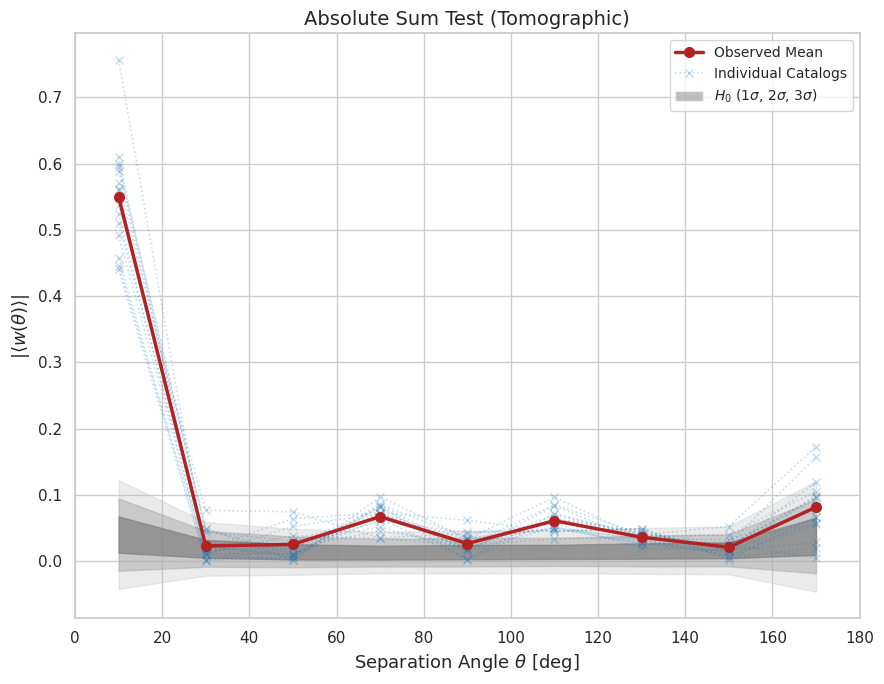

In [18]:
# ==============================================================
# PLOT 2 — Absolute Sum Test
# ==============================================================

from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9,7))

# --- H0 confidence bands (sem label) ---
ax.fill_between(COARSE_CENTERS,
                h0_abs_mean - 3*h0_abs_std,
                h0_abs_mean + 3*h0_abs_std,
                color='silver', alpha=0.3)

ax.fill_between(COARSE_CENTERS,
                h0_abs_mean - 2*h0_abs_std,
                h0_abs_mean + 2*h0_abs_std,
                color='darkgray', alpha=0.5)

ax.fill_between(COARSE_CENTERS,
                h0_abs_mean - h0_abs_std,
                h0_abs_mean + h0_abs_std,
                color='gray', alpha=0.7)


# --- Individual catalogs ---
for i, a in enumerate(all_abs_obs):
    ax.plot(COARSE_CENTERS, a,
            color='tab:blue',
            alpha=0.25,
            lw=1.2,
            marker='x',
            ls=':',
            label="Individual Catalogs" if i == 0 else None)


# --- Observed mean ---
ax.plot(COARSE_CENTERS, mean_abs_obs,
        'o-', color='firebrick',
        markersize=7, lw=2.5,
        label='Observed Mean',
        zorder=10)


# --- Axis settings ---
ax.set_xlabel(r'Separation Angle $\theta$ [deg]')
ax.set_ylabel(r'$|\langle w(\theta) \rangle|$')
ax.set_title('Absolute Sum Test (Tomographic)')

ax.set_xticks(COARSE_BINS)


# --- Custom legend (igual ao Plot 1) ---
h0_patch = Patch(facecolor='gray', alpha=0.5,
                 label=r'$H_0$ (1$\sigma$, 2$\sigma$, 3$\sigma$)')

handles, labels = ax.get_legend_handles_labels()

handle_dict = dict(zip(labels, handles))

legend_handles = [
    handle_dict['Observed Mean'],
    handle_dict['Individual Catalogs'],
    h0_patch
]

legend_labels = [
    'Observed Mean',
    'Individual Catalogs',
    r'$H_0$ (1$\sigma$, 2$\sigma$, 3$\sigma$)'
]

ax.legend(legend_handles, legend_labels,
          frameon=True, loc='upper right')


plt.tight_layout()

# --- Save ---
plt.savefig("FRB_ABS.pdf", bbox_inches='tight')
plt.savefig("FRB_ABS.png", dpi=300, bbox_inches='tight')

plt.show()